In [1]:
import functools
import sys
from pathlib import Path
from typing import Callable

from rich import print as rprint
import math

import circuitsvis as cv
import matplotlib.pyplot as plt
import einops
import numpy as np
import torch as t
import torch.nn as nn
from eindex import eindex
from IPython.display import display
from jaxtyping import Float, Int
from torch import Tensor
from tqdm import tqdm
from transformer_lens import (
    ActivationCache,
    FactoredMatrix,
    HookedTransformer,
    HookedTransformerConfig,
    utils,
)
from transformer_lens.hook_points import HookPoint

t.set_grad_enabled(False)

device = t.device("cuda" if t.cuda.is_available() else "mps" if t.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
cfg = HookedTransformerConfig(
  d_model=768,
  d_head=64,
  n_heads=12,
  n_layers=2,
  n_ctx=2048,
  d_vocab=50278,
  attention_dir="causal",
  attn_only=True,  # defaults to False
  tokenizer_name="EleutherAI/gpt-neox-20b",
  seed=398,
  use_attn_result=True,
  normalization_type=None,  # defaults to "LN", i.e. layernorm with weights & biases
  positional_embedding_type="shortformer",
)

In [3]:
from huggingface_hub import hf_hub_download

REPO_ID = "callummcdougall/attn_only_2L_half"
FILENAME = "attn_only_2L_half.pth"

weights_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)

In [4]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(cfg.tokenizer_name)


In [5]:
model = HookedTransformer(cfg)
pretrained_weights = t.load(weights_path, map_location=device, weights_only=True)
model.load_state_dict(pretrained_weights)

<All keys matched successfully>

In [21]:
text = "We think that powerful, significantly superhuman machine intelligence is more likely than not to be created this century. If current machine learning techniques were scaled up to this level, we think they would by default produce systems that are deceptive or manipulative, and that no solid plans are known for how to avoid this."

logits, cache = model.run_with_cache(text, remove_batch_dim=True)

In [7]:
layer = 0
q, k = cache['q', layer], cache['k', layer]
seq, nhead, headsize = q.shape
attn_scores = einops.einsum(q, k, "q_len n_heads h_dim, k_len n_heads h_dim -> n_heads q_len k_len")
mask = t.triu(t.ones(seq, seq, dtype=t.bool), diagonal=1)
attn_scores.masked_fill_(mask, -1e9)
pattern = t.softmax(attn_scores / headsize**.5, -1)

print("Patterns match:", t.allclose(pattern, cache["pattern", layer], atol=1e-5))

Patterns match: True


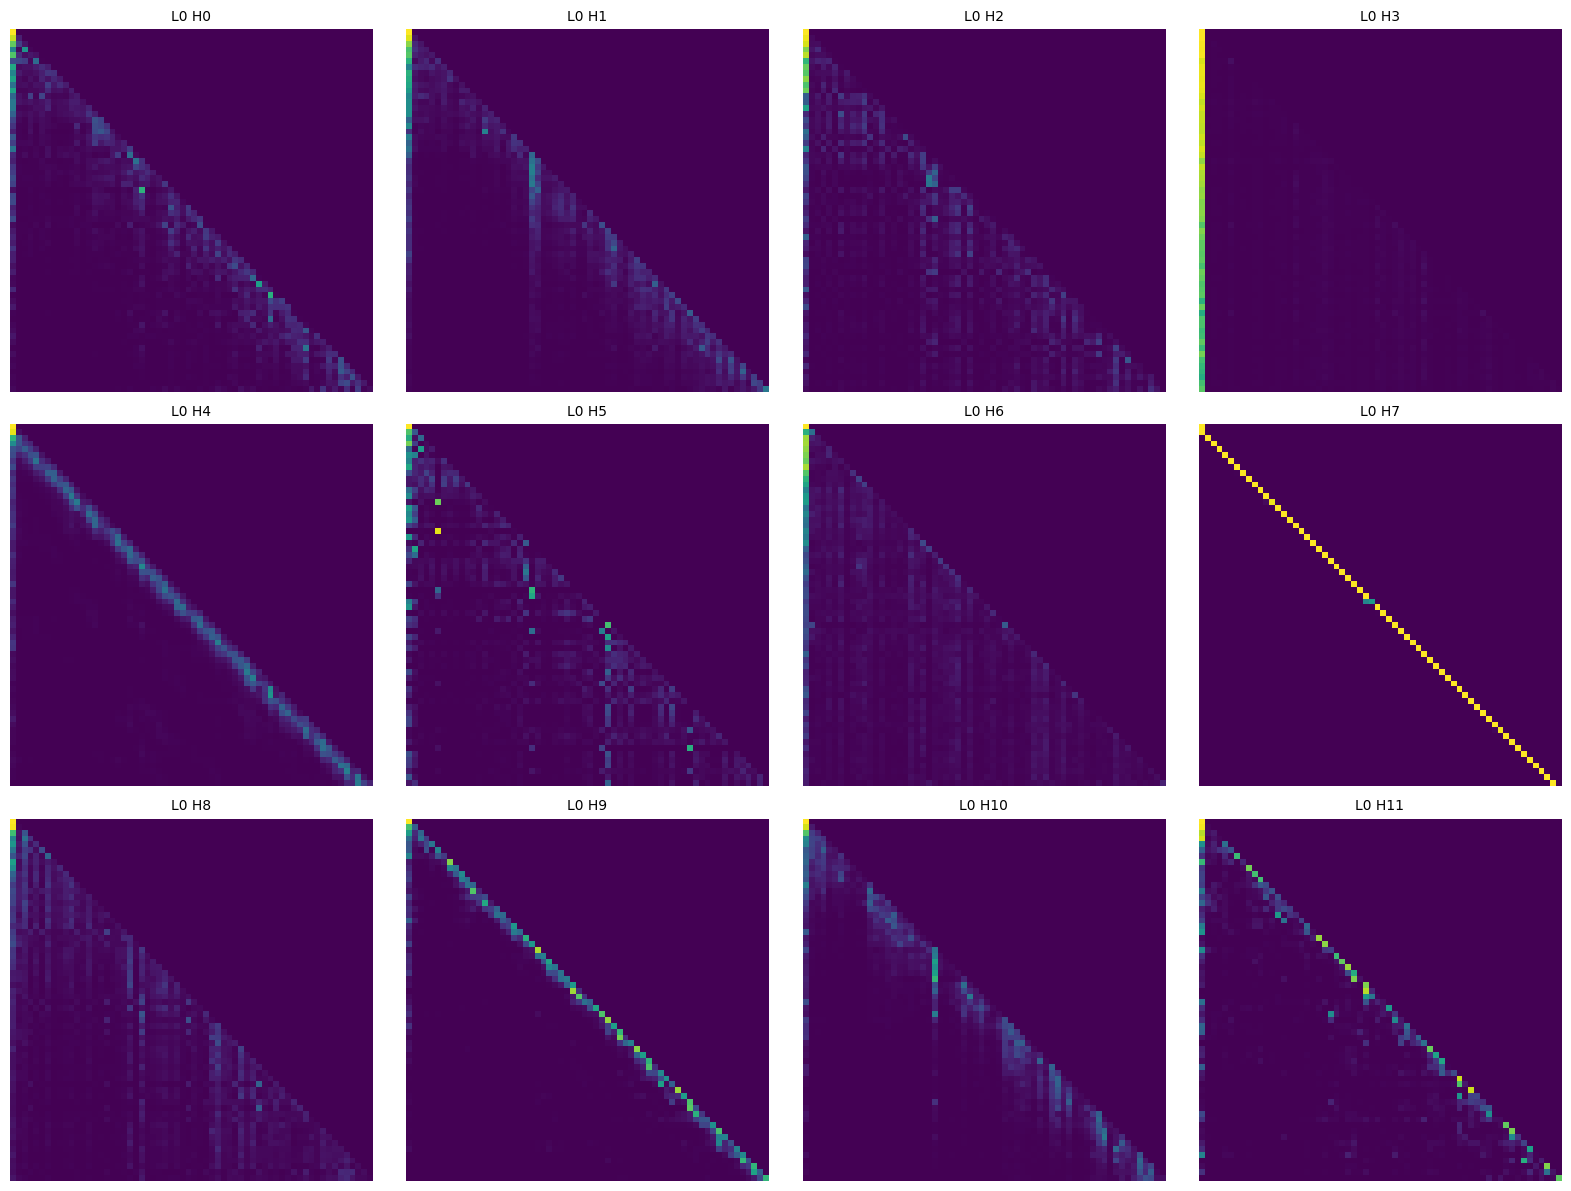

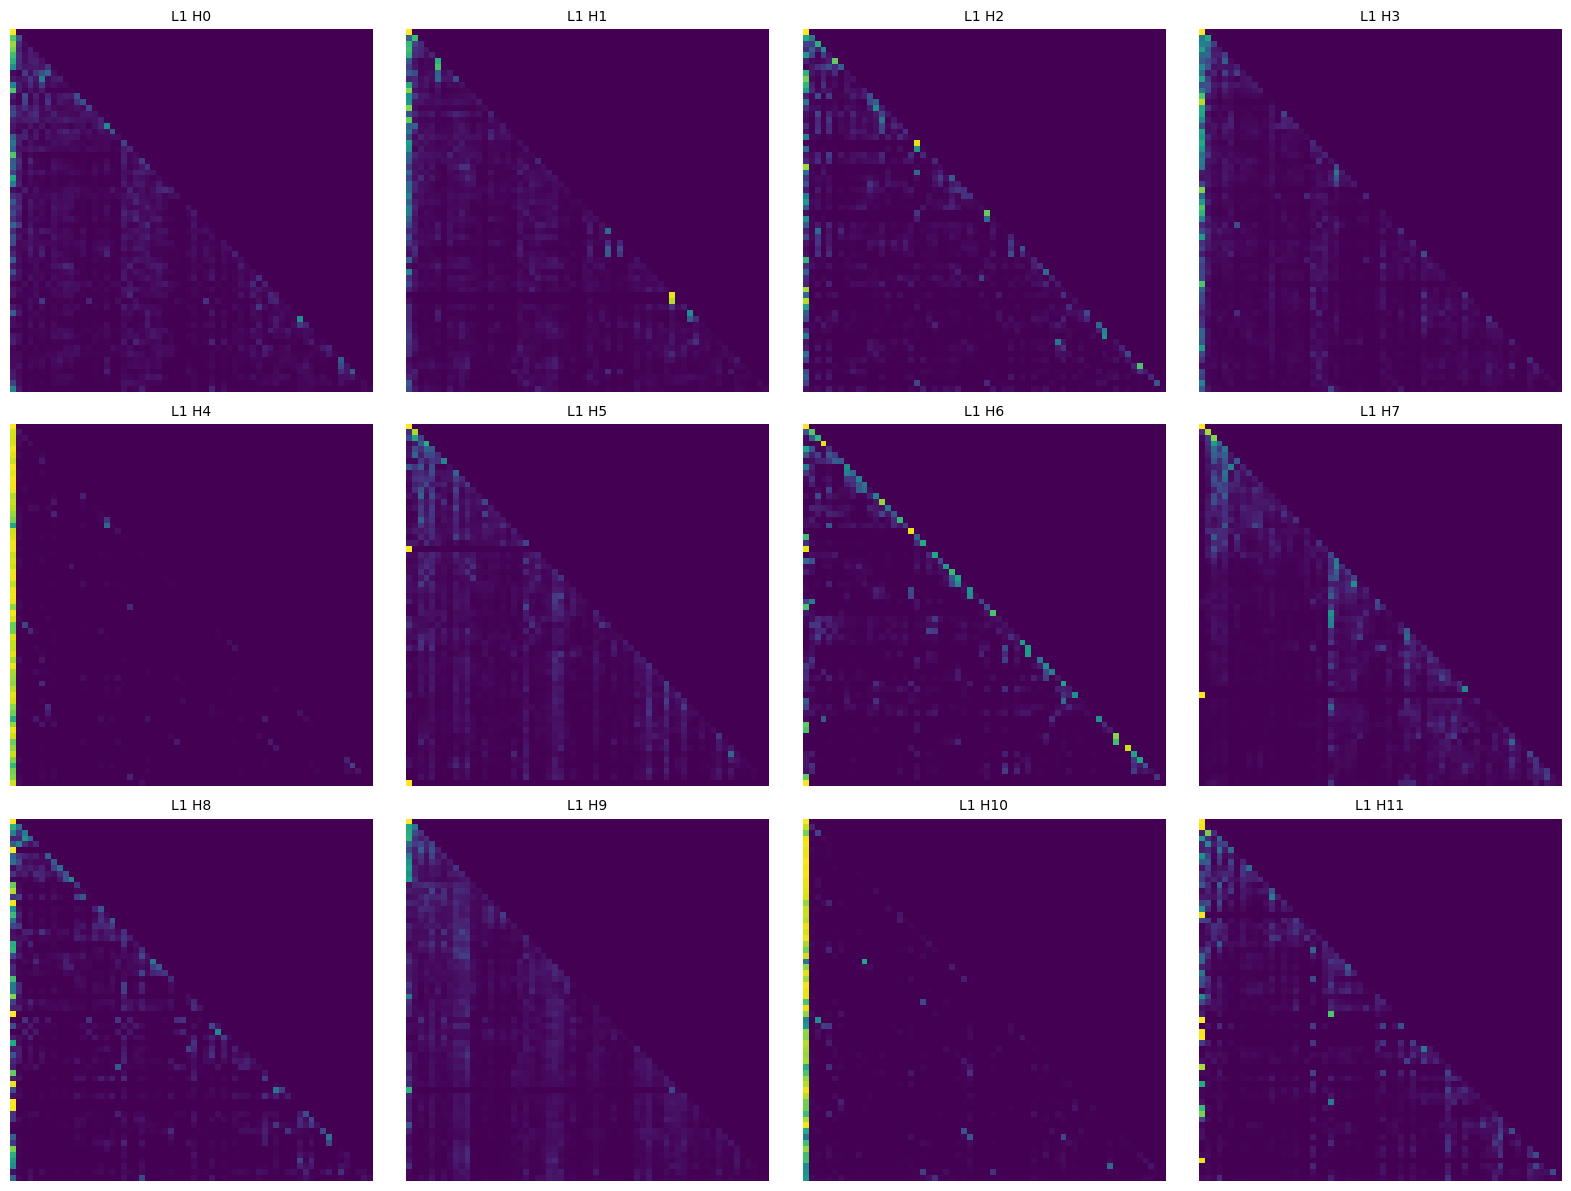

In [39]:
layer = 1
tokens_ids = tokenizer.encode(text)
tokens = [tokenizer.decode(t) for t in tokens_ids]

# display(
#     cv.attention.attention_patterns(
#         tokens=tokens,
#         attention=cache["pattern", 0],
#     )
# )

for layer in [0,1]:

  cols = 4
  rows = math.ceil(cfg.n_heads / cols)
  fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
  axes = axes.flatten() # Flatten to 1D for easy indexing
  for head in range(cfg.n_heads):
    ax = axes[head]
    ax.imshow(cache["pattern", layer][head].cpu().numpy(), cmap='viridis')
    ax.set_title(f"L{layer} H{head}", fontsize=10)
    ax.axis('off') # Optional: hide axes for a cleaner look
        
  for i in range(head + 1, len(axes)):
    axes[i].axis('off')

  plt.tight_layout()
  plt.show()


In [9]:
n_layers = 2
def current_attn_detector(cache: ActivationCache) -> list[str]:
  """
  Returns a list e.g. ["0.2", "1.4", "1.9"] of "layer.head" which you judge to be current-token heads
  """
  threshold = 0.35
  res = []
  for layer in range(n_layers):
    seq, nhead, headsize = cache['q', layer].shape
    mask = t.eye(seq, seq).unsqueeze(0).repeat(nhead, 1, 1)
    similarity = t.sum(t.diagonal(cache['pattern', layer], offset=0, dim1=-2, dim2=-1), axis=-1) / 62
    res += [f"{layer}.{i}" for i in t.where(similarity >= threshold)[0].tolist()]

  return res

def prev_attn_detector(cache: ActivationCache) -> list[str]:
  """
  Returns a list e.g. ["0.2", "1.4", "1.9"] of "layer.head" which you judge to be prev-token heads
  """
  threshold = 0.35
  res = []
  for layer in range(n_layers):
    seq, nhead, headsize = cache['q', layer].shape
    similarity = t.sum(t.tril(t.triu(cache['pattern', layer], diagonal=-1), diagonal=-1), dim=(1,2)) / seq
    res += [f"{layer}.{i}" for i in t.where(similarity >= threshold)[0].tolist()]
  return res


def first_attn_detector(cache: ActivationCache) -> list[str]:
  """
  Returns a list e.g. ["0.2", "1.4", "1.9"] of "layer.head" which you judge to be first-token heads
  """
  threshold = 0.35
  res = []
  for layer in range(n_layers):
    similarity = t.sum(cache['pattern', layer][:, :, 0], axis=-1) / 62
    res += [f"{layer}.{i}" for i in t.where(similarity >= threshold)[0].tolist()]
  return res


print("Heads attending to current token  = ", ", ".join(current_attn_detector(cache)))
print("Heads attending to previous token = ", ", ".join(prev_attn_detector(cache)))
print("Heads attending to first token    = ", ", ".join(first_attn_detector(cache)))

Heads attending to current token  =  0.9, 0.11, 1.6
Heads attending to previous token =  0.7
Heads attending to first token    =  0.3, 1.3, 1.4, 1.8, 1.10


In [10]:
import numpy as np
import plotly.graph_objects as go
import torch as t

def plot_loss_difference(log_probs, rep_str, seq_len):
    # Convert tensor -> numpy
    y = log_probs.detach().cpu().numpy() if isinstance(log_probs, t.Tensor) else np.asarray(log_probs)

    # Handle token list shape: ["<BOS>", ...] or [["<BOS>", ...]]
    tokens = rep_str[0] if isinstance(rep_str[0], list) else rep_str

    # log_probs predicts next token, so align hover token with tokens[1:]
    hover_tokens = np.array(tokens[1:len(y)+1], dtype=object)
    x = np.arange(1, len(y) + 1)

    first = x <= seq_len
    second = x > seq_len

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=x[first],
        y=y[first],
        mode="lines+markers",
        name="First half targets",
        line=dict(width=2, color="#1f77b4"),
        marker=dict(size=5),
        customdata=hover_tokens[first],
        hovertemplate="pos=%{x}<br>token=%{customdata}<br>log p=%{y:.3f}<extra></extra>",
    ))

    fig.add_trace(go.Scatter(
        x=x[second],
        y=y[second],
        mode="lines+markers",
        name="Second half targets",
        line=dict(width=2, color="#ff7f0e"),
        marker=dict(size=5),
        customdata=hover_tokens[second],
        hovertemplate="pos=%{x}<br>token=%{customdata}<br>log p=%{y:.3f}<extra></extra>",
    ))

    fig.add_vline(x=seq_len + 0.5, line_dash="dash", line_color="gray")
    fig.add_annotation(
        x=seq_len + 0.5,
        y=float(np.max(y)),
        text="split",
        showarrow=False,
        yshift=10,
        font=dict(color="gray"),
    )

    fig.update_layout(
        title="Next-token log probability across repeated-token sequence",
        xaxis_title="Position",
        yaxis_title="Log probability",
        template="plotly_white",
        hovermode="x unified",
        legend=dict(orientation="h", y=1.08, x=0),
    )
    fig.show()

    # Optional summary chart (mean comparison)
    fig2 = go.Figure(go.Bar(
        x=["First half", "Second half"],
        y=[float(y[:seq_len].mean()), float(y[seq_len:].mean())],
        marker_color=["#1f77b4", "#ff7f0e"],
        text=[f"{y[:seq_len].mean():.3f}", f"{y[seq_len:].mean():.3f}"],
        textposition="outside",
    ))
    fig2.update_layout(
        title="Mean log probability by half",
        yaxis_title="Mean log probability",
        template="plotly_white",
    )
    fig2.show()

In [11]:
def generate_repeated_tokens(model: HookedTransformer, seq_len: int, batch_size: int = 1) -> Int[Tensor, "batch_size full_seq_len"]:
  """
  Generates a sequence of repeated random tokens
  Outputs are:
    rep_tokens: [batch_size, 1+2*seq_len]
  """
  t.manual_seed(0)
  prefix = (t.ones(batch_size, 1) * model.tokenizer.bos_token_id).long().to(device)

  seq = t.randint(low=1, high=model.tokenizer.vocab_size, size=(batch_size, seq_len), dtype=t.long, device=device)
  
  return t.cat((prefix, seq, seq), dim=1)

def run_and_cache_model_repeated_tokens(model: HookedTransformer, seq_len: int, batch_size: int = 1) -> tuple[Tensor, Tensor, ActivationCache]:
  """
  Generates a sequence of repeated random tokens, and runs the model on it, returning (tokens,
  logits, cache). This function should use the `generate_repeated_tokens` function above.
  Outputs are:
    rep_tokens: [batch_size, 1+2*seq_len]
    rep_logits: [batch_size, 1+2*seq_len, d_vocab]
    rep_cache: The cache of the model run on rep_tokens
  """
  tokens = generate_repeated_tokens(model, seq_len)
  logits, cache = model.run_with_cache(tokens, remove_batch_dim=True)
  return tokens, logits, cache


def get_log_probs(logits: Float[Tensor, "batch posn d_vocab"], tokens: Int[Tensor, "batch posn"]) -> Float[Tensor, "batch posn-1"]:
  logprobs = logits.log_softmax(dim=-1)
  # We want to get logprobs[b, s, tokens[b, s+1]], in eindex syntax this looks like:

  correct_logprobs = eindex(logprobs, tokens, "b s [b s+1]")
  return correct_logprobs


seq_len = 50
batch_size = 1
(rep_tokens, rep_logits, rep_cache) = run_and_cache_model_repeated_tokens(model, seq_len, batch_size)
rep_str = model.to_str_tokens(rep_tokens)
model.reset_hooks()
log_probs = get_log_probs(rep_logits, rep_tokens).squeeze()

print(f"Performance on the first half: {log_probs[:seq_len].mean():.3f}")
print(f"Performance on the second half: {log_probs[seq_len:].mean():.3f}")

plot_loss_difference(log_probs, rep_str, seq_len)


/home/figini/Documents/projects/arena/.venv/lib/python3.13/site-packages/eindex/indexing.py:289: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  assert torch.tensor(shape).prod().item() == index_tensor[idx].numel(), \
/home/figini/Documents/projects/arena/.venv/lib/python3.13/site-packages/eindex/indexing.py:293: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autogra

Performance on the first half: -14.170
Performance on the second half: -5.021


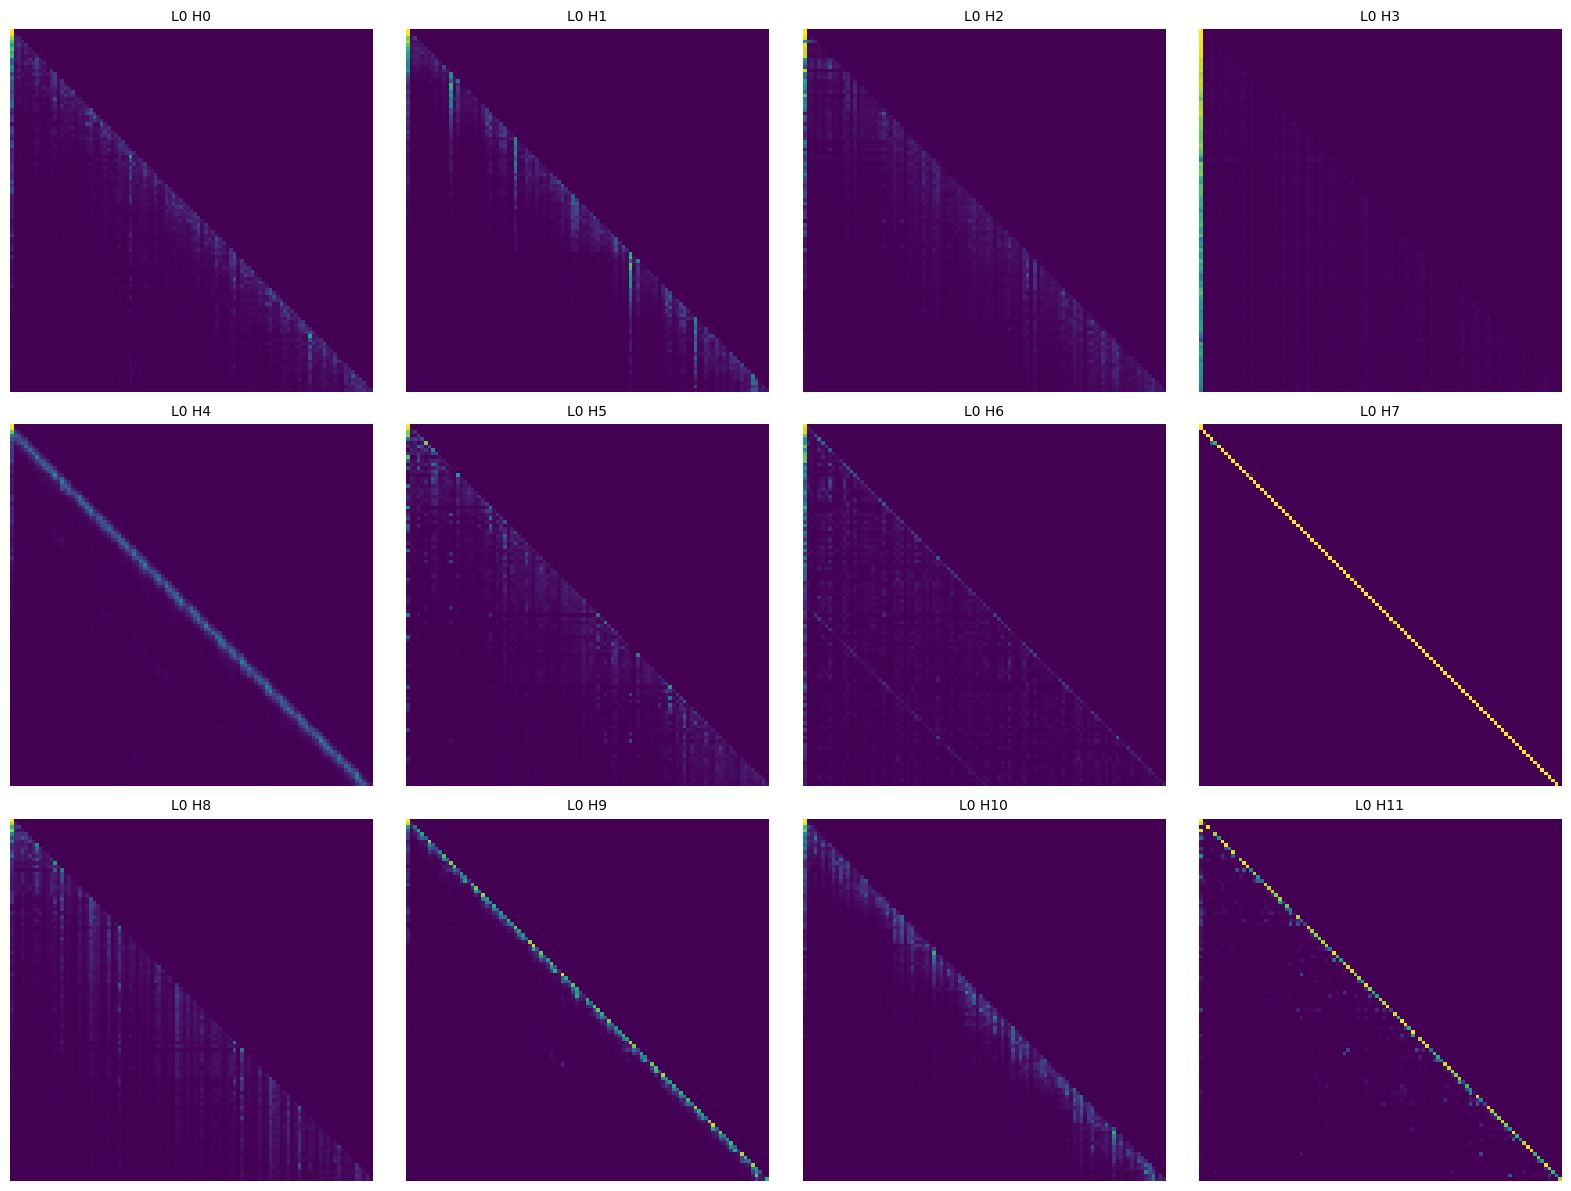

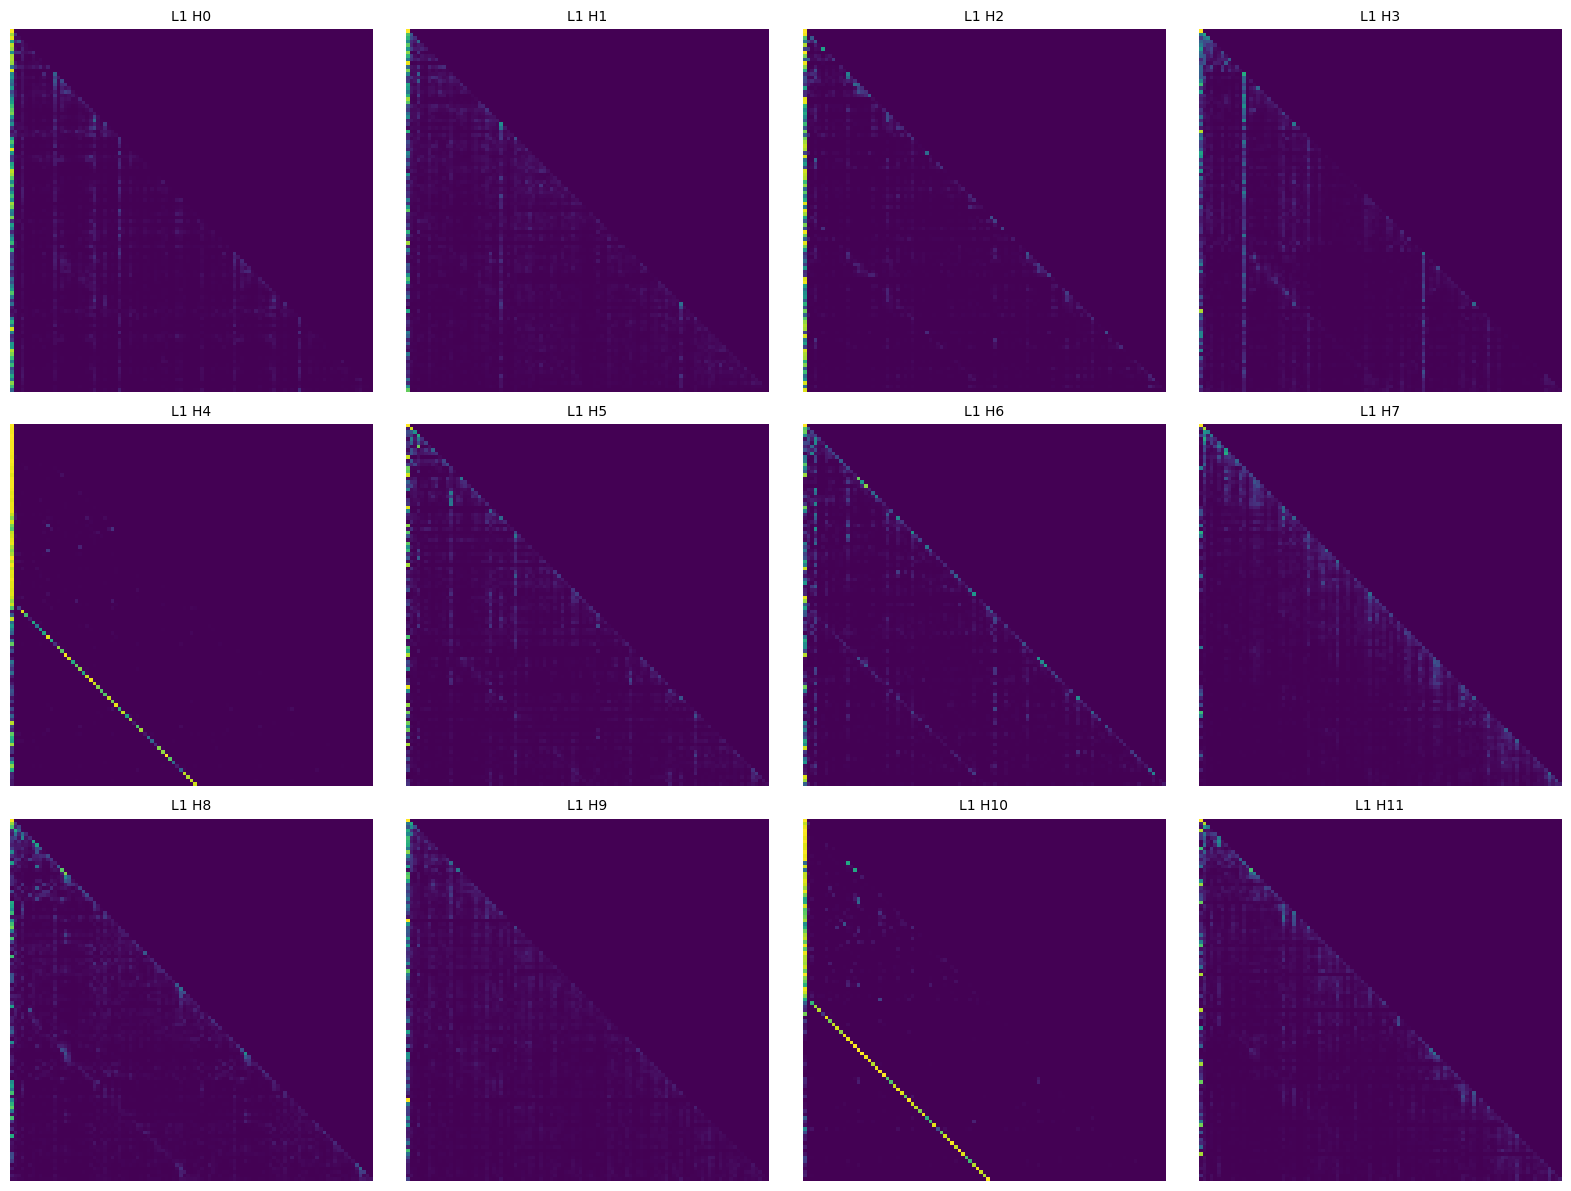

In [12]:
cols = 4
tokens_ids = tokenizer.encode(text)
tokens = [tokenizer.decode(t) for t in tokens_ids]
for layer in [0,1]:
  rows = math.ceil(cfg.n_heads / cols)
  fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
  axes = axes.flatten() # Flatten to 1D for easy indexing
  for head in range(cfg.n_heads):
    ax = axes[head]
    ax.imshow(rep_cache["pattern", layer][head].cpu().numpy(), cmap='viridis')
    ax.set_title(f"L{layer} H{head}", fontsize=10)
    ax.axis('off') # Optional: hide axes for a cleaner look
        
  for i in range(head + 1, len(axes)):
    axes[i].axis('off')

  plt.tight_layout()
  plt.show()

In [13]:
def induction_attn_detector(cache: ActivationCache) -> list[str]:
  """
  Returns a list e.g. ["0.2", "1.4", "1.9"] of "layer.head" which you judge to be induction heads
  Remember - the tokens used to generate rep_cache are (bos_token, *rand_tokens, *rand_tokens)
  """
  threshold = 0.3
  res = []
  for layer in range(n_layers):
    seq, nhead, headsize = cache['q', layer].shape
    similarity = t.sum(t.triu(t.tril(cache["pattern", layer], diagonal=-seq_len+1), diagonal=-seq_len+1), dim=(1,2)) / seq
    res += [f"{layer}.{i}" for i in t.where(similarity >= threshold)[0].tolist()]
  return res


print("Induction heads = ", ", ".join(induction_attn_detector(rep_cache)))

Induction heads =  1.4, 1.10


In [14]:
import plotly.express as px
seq_len = 50
batch_size = 10
rep_tokens_10 = generate_repeated_tokens(model, seq_len, batch_size)

# We make a tensor to store the induction score for each head.
# We put it on the model's device to avoid needing to move things between the GPU and CPU,
# which can be slow.
induction_score_store = t.zeros((model.cfg.n_layers, model.cfg.n_heads), device=model.cfg.device)

def induction_score_hook(pattern: Float[Tensor, "batch head_index dest_pos source_pos"], hook: HookPoint):
  """
  Calculates the induction score, and stores it in the [layer, head] position of the
  `induction_score_store` tensor.
  """
  rprint(pattern.shape)
  induction_stripe = pattern.diagonal(dim1=-2, dim2=-1, offset=1 - seq_len)
  induction_score = einops.reduce(induction_stripe, "batch head_index position -> head_index", "mean")
  induction_score_store[hook.layer()] = induction_score


# We make a boolean filter on activation names, that's true only on attention pattern names
pattern_hook_names_filter = lambda name: name.endswith("pattern")

# Run with hooks (this is where we write to the `induction_score_store` tensor`)
model.run_with_hooks(
    rep_tokens_10,
    return_type=None,  # For efficiency, we don't need to calculate the logits
    fwd_hooks=[(pattern_hook_names_filter, induction_score_hook)],
)

# Plot the induction scores for each head in each layer
fig = px.imshow(
    induction_score_store.detach().cpu().numpy(),
    labels={"x": "Head", "y": "Layer"},
    title="Induction Score by Head",
    text_auto=".2f",
    aspect="auto",
)
fig.update_layout(width=900, height=350)
fig.show()


torch.Size([10, 12, 101, 101])

torch.Size([10, 12, 101, 101])

In [15]:
gpt2_small = HookedTransformer.from_pretrained(
  "gpt2-small",
  fold_ln=False,
  center_unembed=False,
  center_writing_weights=False,
)


induction_score_store = t.zeros((gpt2_small.cfg.n_layers, model.cfg.n_heads), device=model.cfg.device)

def induction_score_hook(pattern: Float[Tensor, "batch head_index dest_pos source_pos"], hook: HookPoint):
  """
  Calculates the induction score, and stores it in the [layer, head] position of the
  `induction_score_store` tensor.
  """
  induction_stripe = pattern.diagonal(dim1=-2, dim2=-1, offset=1 - seq_len)
  induction_score = einops.reduce(induction_stripe, "batch head_index position -> head_index", "mean")
  induction_score_store[hook.layer()] = induction_score

def visualize_pattern_hook(
  pattern: Float[Tensor, "batch head_index dest_pos source_pos"],
  hook: HookPoint,
):
  print("Layer: ", hook.layer())
  display(cv.attention.attention_patterns(tokens=gpt2_small.to_str_tokens(rep_tokens[0]), attention=pattern.mean(0)))


pattern_hook_names_filter = lambda name: name.endswith("pattern")

gpt2_small.run_with_hooks(
    rep_tokens_10,
    return_type=None,
    fwd_hooks=[(pattern_hook_names_filter, induction_score_hook),
              #  (pattern_hook_names_filter, visualize_pattern_hook)
               ],
)

fig = px.imshow(
    induction_score_store.detach().cpu().numpy(),
    labels={"x": "Head", "y": "Layer"},
    title="Induction Score by Head",
    text_auto=".2f",
    aspect="auto",
)
fig.show()


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2-small into HookedTransformer


In [16]:
import torch.nn.functional as F

def logit_attribution(
    embed: Float[Tensor, "seq d_model"],
    l1_results: Float[Tensor, "seq nheads d_model"],
    l2_results: Float[Tensor, "seq nheads d_model"],
    W_U: Float[Tensor, "d_model d_vocab"],
    tokens: Int[Tensor, "seq"],
) -> Float[Tensor, "seq-1 n_components"]:
  """
  Inputs:
      embed: the embeddings of the tokens (i.e. token + position embeddings)
      l1_results: the outputs of the attention heads at layer 1 (with head as one of the dims)
      l2_results: the outputs of the attention heads at layer 2 (with head as one of the dims)
      W_U: the unembedding matrix
      tokens: the token ids of the sequence
  Returns:
      Tensor of shape (seq_len-1, n_components)
      represents the concatenation (along dim=-1) of logit attributions from:
          the direct path (seq-1,1)
          layer 0 logits (seq-1, n_heads)
          layer 1 logits (seq-1, n_heads)
      so n_components = 1 + 2*n_heads
  """
  W_U_correct_tokens = W_U[:, tokens[1:]]
  direct_attributions = einops.einsum(W_U_correct_tokens, embed[:-1], "emb seq, seq emb -> seq")
  l1_attributions = einops.einsum(W_U_correct_tokens, l1_results[:-1], "emb seq, seq nhead emb -> seq nhead")
  l2_attributions = einops.einsum(W_U_correct_tokens, l2_results[:-1], "emb seq, seq nhead emb -> seq nhead")
  return t.concat([direct_attributions.unsqueeze(-1), l1_attributions, l2_attributions], dim=-1)

text = "We think that powerful, significantly superhuman machine intelligence is more likely than not to be created this century. If current machine learning techniques were scaled up to this level, we think they would by default produce systems that are deceptive or manipulative, and that no solid plans are known for how to avoid this."
logits, cache = model.run_with_cache(text, remove_batch_dim=True)
str_tokens = model.to_str_tokens(text)
tokens = model.to_tokens(text)

In [17]:
import plotly.express as px

def plot_logit_attribution_heatmap(
    logit_attr: t.Tensor,
    token_labels: list[str],
    component_labels: list[str],
    title: str = "Logit Attribution by Token and Component",
    min_width: int = 1000,
    min_height: int = 2000,
    cell_width: int = 45,
    cell_height: int = 22,
) -> None:
    """Plot a readable attribution heatmap with token labels on the y-axis."""
    values = logit_attr.detach().cpu().numpy() if isinstance(logit_attr, t.Tensor) else np.asarray(logit_attr)
    n_rows, n_cols = values.shape

    fig = px.imshow(
        values,
        x=component_labels,
        y=token_labels,
        labels={"x": "Component", "y": "Next token", "color": "Attribution"},
        title=title,
        color_continuous_scale="RdBu",
        color_continuous_midpoint=0,
        aspect="auto",
    )

    fig.update_layout(
        width=max(min_width, cell_width * n_cols),
        height=max(min_height, cell_height * n_rows),
        margin=dict(l=100, r=40, t=70, b=120),
    )
    fig.update_xaxes(tickangle=-45)
    fig.update_yaxes(automargin=True)
    fig.show()


embed = cache["embed"]
l1_results = cache["result", 0]
l2_results = cache["result", 1]
logit_attr = logit_attribution(embed, l1_results, l2_results, model.W_U, tokens.squeeze())

token_labels = model.to_str_tokens(tokens.squeeze())[1:]
n_heads = l1_results.shape[1]
component_labels = ["Direct"] + [f"L0H{h}" for h in range(n_heads)] + [f"L1H{h}" for h in range(n_heads)]

plot_logit_attribution_heatmap(
    logit_attr=logit_attr,
    token_labels=token_labels,
    component_labels=component_labels,
    title="Logit Attribution by Token and Component",
)

In [18]:
embed = rep_cache["embed"]
l1_results = rep_cache["result", 0]
l2_results = rep_cache["result", 1]
logit_attr = logit_attribution(embed, l1_results, l2_results, model.W_U, rep_tokens.squeeze())

token_labels = model.to_str_tokens(rep_tokens.squeeze())[1:]
n_heads = l1_results.shape[1]
component_labels = ["Direct"] + [f"L0H{h}" for h in range(n_heads)] + [f"L1H{h}" for h in range(n_heads)]

plot_logit_attribution_heatmap(
    logit_attr=logit_attr,
    token_labels=token_labels,
    component_labels=component_labels,
    title="Logit Attribution by Token and Component",
)

In [31]:
def head_zero_ablation_hook(
  z: Float[Tensor, "batch seq n_heads d_head"],
  hook: HookPoint,
  head_index_to_ablate: int,
) -> None:
  z[:, :, head_index_to_ablate, :] = 0

def get_ablation_scores(
  model: HookedTransformer,
  tokens: Int[Tensor, "batch seq"],
  ablation_function: Callable = head_zero_ablation_hook,
) -> Float[Tensor, "n_layers n_heads"]:
  """
  Returns a tensor of shape (n_layers, n_heads) containing the increase in cross entropy loss
  from ablating the output of each head.
  """
  # Initialize an object to store the ablation scores
  ablation_scores = t.zeros((model.cfg.n_layers, model.cfg.n_heads), device=model.cfg.device)

  # Calculating loss without any ablation, to act as a baseline
  model.reset_hooks()
  seq_len = (tokens.shape[1] - 1) // 2
  logits = model(tokens, return_type="logits")
  get_loss = lambda log: -get_log_probs(log, tokens)[:, -(seq_len - 1) :].mean()
  loss_no_ablation = get_loss(logits)

  for layer in tqdm(range(model.cfg.n_layers)):
    for head in range(model.cfg.n_heads):
      hook_fn = functools.partial(ablation_function, head_index_to_ablate=head)
      logits = model.run_with_hooks(tokens, 
                                    return_type="logits",
                                    fwd_hooks=[(utils.get_act_name("z", layer), hook_fn)])
      ablation_scores[layer, head] = get_loss(logits) - loss_no_ablation 

  return ablation_scores

model.run_with_hooks(
    rep_tokens_10,
    return_type=None,  # For efficiency, we don't need to calculate the logits
    fwd_hooks=[(pattern_hook_names_filter, induction_score_hook)],
)

ablation_scores = get_ablation_scores(model, rep_tokens)

import plotly.express as px
fig = px.imshow(
    ablation_scores.detach().cpu().numpy(),
    labels={"x": "Head", "y": "Layer", "color": "Logit diff"},
    title="Loss Difference After Ablating Heads",
    text_auto=".2f",
    width=900,
    height=350,
)
fig.show()


100%|██████████| 2/2 [00:05<00:00,  2.75s/it]


In [36]:
def head_mean_ablation_hook(
    z: Float[Tensor, "batch seq n_heads d_head"],
    hook: HookPoint,
    head_index_to_ablate: int,
) -> None:
  z[:, :, head_index_to_ablate, :] = z[:, :, head_index_to_ablate, :].mean(0)

rep_tokens_batch = run_and_cache_model_repeated_tokens(model, seq_len=50, batch_size=10)[0]
mean_ablation_scores = get_ablation_scores(model, rep_tokens_batch, ablation_function=head_mean_ablation_hook)

fig = px.imshow(
    ablation_scores.detach().cpu().numpy(),
    labels={"x": "Head", "y": "Layer", "color": "Logit diff"},
    title="Loss Difference After Ablating Heads",
    text_auto=".2f",
    width=900,
    height=350,
)
fig.show()

/home/figini/Documents/projects/arena/.venv/lib/python3.13/site-packages/eindex/indexing.py:289: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  assert torch.tensor(shape).prod().item() == index_tensor[idx].numel(), \
/home/figini/Documents/projects/arena/.venv/lib/python3.13/site-packages/eindex/indexing.py:293: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autogra